In [1]:
from time import time
import mininumpy as mnp
import random
import matplotlib.pyplot as plt
import tracemalloc

In [2]:


def test(dims, num_runs=10):
    """
    Test naive vs Strassen matrix multiplication for given dimensions.
    
    Args:
        dims: List of matrix dimensions to test
        num_runs: Number of runs per dimension (default: 10)
    
    Returns:
        dict: Dictionary containing test results with keys:
            - 'dims': list of dimensions tested
            - 'naive_times': list of average times for naive method
            - 'strassen_times': list of average times for Strassen method
            - 'naive_memory': list of average peak memory for naive method
            - 'strassen_memory': list of average peak memory for Strassen method
    """
    naive_avgs = []
    strassen_avgs = []
    naive_mem_avgs = []
    strassen_mem_avgs = []
    
    for dim in dims:
        print(f"\n=== Dimension: {dim}x{dim} ===")
        
        naive_times = []
        strassen_times = []
        naive_mems = []
        strassen_mems = []
        
        for run in range(num_runs):
            A = [[random.randint(1, 10) for _ in range(dim)] for _ in range(dim)]
            B = [[random.randint(1, 10) for _ in range(dim)] for _ in range(dim)]
            mat_A = mnp.Array(A)
            mat_B = mnp.Array(B)

            # Naive multiplication
            tracemalloc.start()
            start_naive = time()
            mnp.minilinalg.matmul(mat_A, mat_B)
            stop_naive = time()
            current, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            naive_times.append(stop_naive - start_naive)
            naive_mems.append(peak / 1024 / 1024)  # Convert to MB

            # Strassen multiplication
            tracemalloc.start()
            start_strassen = time()
            mnp.minilinalg.matmul(mat_A, mat_B, algo="strassen")
            stop_strassen = time()
            current, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            strassen_times.append(stop_strassen - start_strassen)
            strassen_mems.append(peak / 1024 / 1024)  # Convert to MB
        
        avg_naive = sum(naive_times) / num_runs
        avg_strassen = sum(strassen_times) / num_runs
        avg_naive_mem = sum(naive_mems) / num_runs
        avg_strassen_mem = sum(strassen_mems) / num_runs
        
        naive_avgs.append(avg_naive)
        strassen_avgs.append(avg_strassen)
        naive_mem_avgs.append(avg_naive_mem)
        strassen_mem_avgs.append(avg_strassen_mem)
        
        print(f"Naive avg:    {avg_naive:.6f} sec | Memory: {avg_naive_mem:.2f} MB")
        print(f"Strassen avg: {avg_strassen:.6f} sec | Memory: {avg_strassen_mem:.2f} MB")
        print(f"Time ratio:   {avg_strassen/avg_naive:.2f}x slower")
        print(f"Memory ratio: {avg_strassen_mem/avg_naive_mem:.2f}x more")
    
    return {
        'dims': dims,
        'naive_times': naive_avgs,
        'strassen_times': strassen_avgs,
        'naive_memory': naive_mem_avgs,
        'strassen_memory': strassen_mem_avgs
    }

def plot(results):
    """
    Plot test results comparing naive vs Strassen methods.
    
    Args:
        results: Dictionary returned by test() function
    """
    dims = results['dims']
    naive_times = results['naive_times']
    strassen_times = results['strassen_times']
    naive_memory = results['naive_memory']
    strassen_memory = results['strassen_memory']
    
    # Calculate ratios
    time_ratios = [s/n for s, n in zip(strassen_times, naive_times)]
    memory_ratios = [s/n for s, n in zip(strassen_memory, naive_memory)]
    
    # Create 2x2 subplot
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    
    # Time comparison
    ax1.plot(dims, naive_times, marker='o', label='Naive', linewidth=2, color='blue')
    ax1.plot(dims, strassen_times, marker='s', label='Strassen', linewidth=2, color='red')
    ax1.set_xlabel('Matrix Dimension (n×n)')
    ax1.set_ylabel('Average Time (seconds)')
    ax1.set_title('Execution Time Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Memory comparison
    ax2.plot(dims, naive_memory, marker='o', label='Naive', linewidth=2, color='blue')
    ax2.plot(dims, strassen_memory, marker='s', label='Strassen', linewidth=2, color='red')
    ax2.set_xlabel('Matrix Dimension (n×n)')
    ax2.set_ylabel('Peak Memory Usage (MB)')
    ax2.set_title('Memory Usage Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Time ratio
    ax3.plot(dims, time_ratios, marker='D', linewidth=2, color='green')
    ax3.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Equal performance')
    ax3.set_xlabel('Matrix Dimension (n×n)')
    ax3.set_ylabel('Ratio (Strassen / Naive)')
    ax3.set_title('Time Ratio (Strassen / Naive)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Memory ratio
    ax4.plot(dims, memory_ratios, marker='D', linewidth=2, color='purple')
    ax4.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Equal usage')
    ax4.set_xlabel('Matrix Dimension (n×n)')
    ax4.set_ylabel('Ratio (Strassen / Naive)')
    ax4.set_title('Memory Ratio (Strassen / Naive)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



In [3]:
dims = [10, 50, 100, 150, 200]
result1 = test(dims, num_runs=1)


=== Dimension: 10x10 ===
Naive avg:    0.001503 sec | Memory: 0.01 MB
Strassen avg: 0.005638 sec | Memory: 0.03 MB
Time ratio:   3.75x slower
Memory ratio: 3.16x more

=== Dimension: 50x50 ===
Naive avg:    0.085321 sec | Memory: 0.16 MB
Strassen avg: 0.359179 sec | Memory: 0.59 MB
Time ratio:   4.21x slower
Memory ratio: 3.69x more

=== Dimension: 100x100 ===
Naive avg:    0.554602 sec | Memory: 0.61 MB
Strassen avg: 2.584500 sec | Memory: 2.35 MB
Time ratio:   4.66x slower
Memory ratio: 3.82x more

=== Dimension: 150x150 ===
Naive avg:    1.690429 sec | Memory: 1.38 MB
Strassen avg: 15.242107 sec | Memory: 8.24 MB
Time ratio:   9.02x slower
Memory ratio: 5.98x more

=== Dimension: 200x200 ===
Naive avg:    3.850538 sec | Memory: 2.45 MB
Strassen avg: 18.105334 sec | Memory: 9.49 MB
Time ratio:   4.70x slower
Memory ratio: 3.88x more


In [4]:
dims = [128, 256, 512]
result2 = test(dims, num_runs=1)


=== Dimension: 128x128 ===
Naive avg:    1.100592 sec | Memory: 1.01 MB
Strassen avg: 2.735319 sec | Memory: 2.72 MB
Time ratio:   2.49x slower
Memory ratio: 2.70x more

=== Dimension: 256x256 ===
Naive avg:    7.502871 sec | Memory: 4.01 MB
Strassen avg: 20.788812 sec | Memory: 11.09 MB
Time ratio:   2.77x slower
Memory ratio: 2.77x more

=== Dimension: 512x512 ===
Naive avg:    86.781709 sec | Memory: 16.01 MB
Strassen avg: 162.810447 sec | Memory: 45.03 MB
Time ratio:   1.88x slower
Memory ratio: 2.81x more


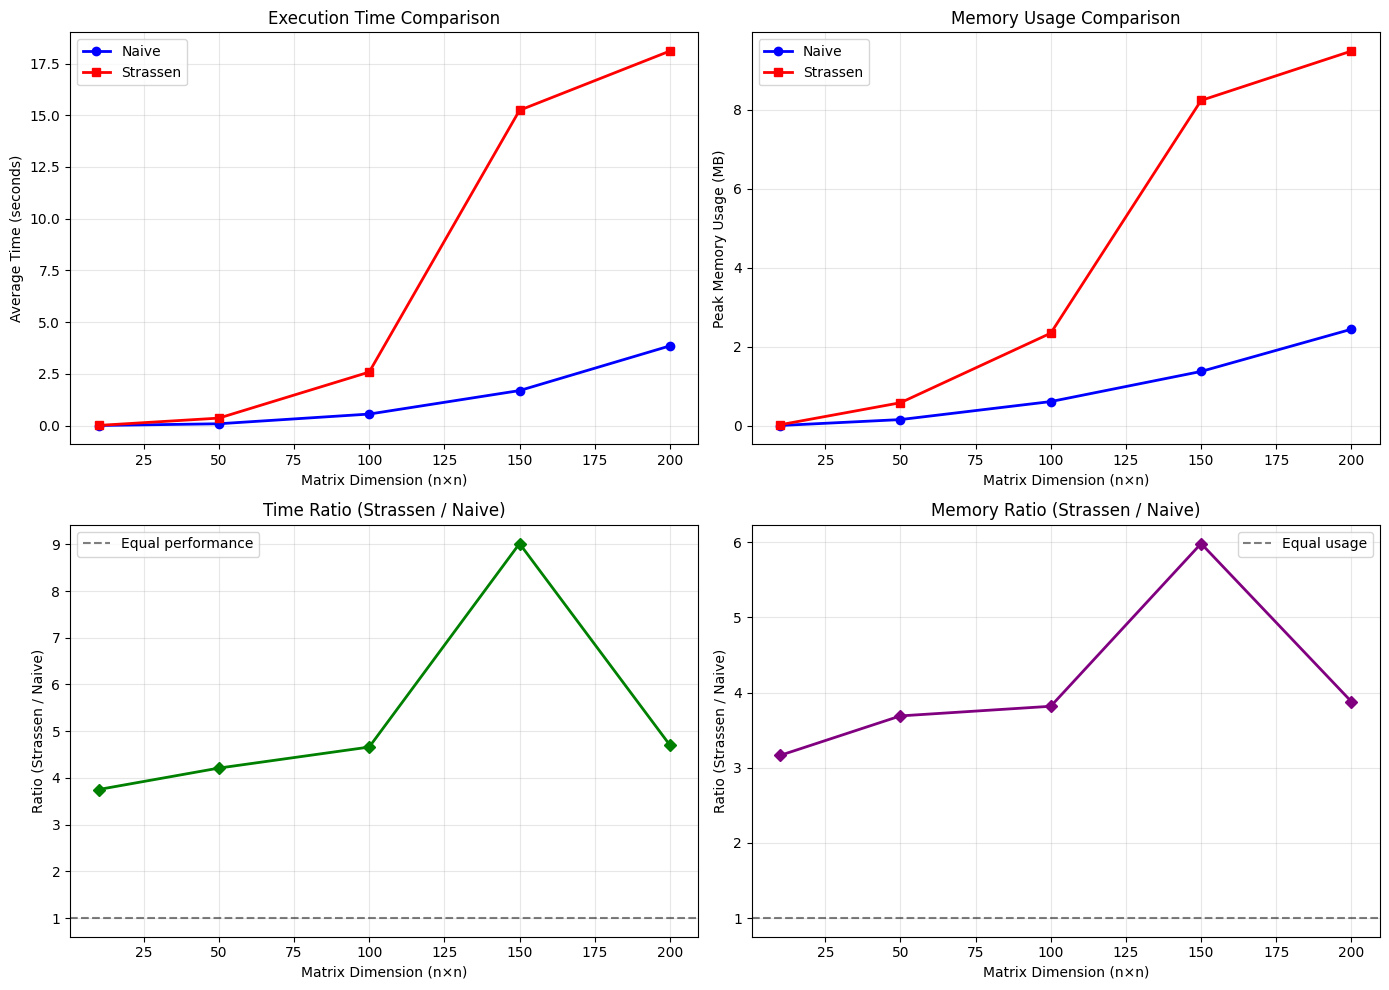

In [5]:
plot(result1)

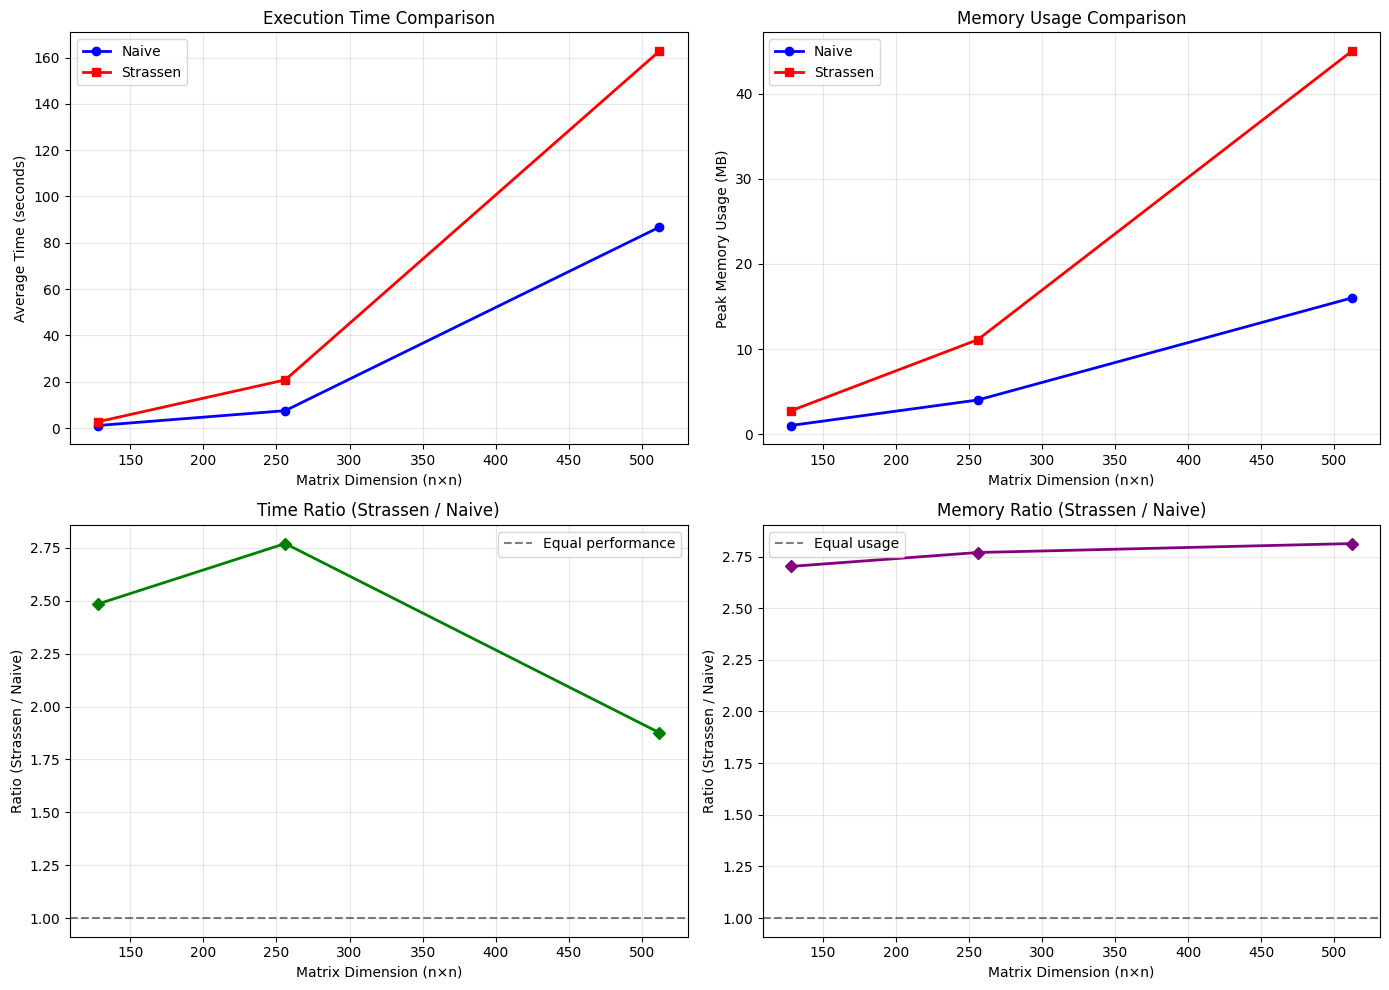

In [6]:
plot(result2)